# 🤖 LangGraph: Single-Node LLM Q&A Workflow

### 📌 Overview
This notebook demonstrates integrating a **Large Language Model (LLM)** into a LangGraph workflow. Building upon pure Python nodes, this workflow executes a single-node graph where an LLM consumes input state and produces an output response.

---

### 🗺️ Graph Topology

```text
┌─────────┐       ┌────────────┐       ┌───────┐
│  START  │ ────► │   llm_qa   │ ────► │  END  │
└─────────┘       └────────────┘       └───────┘
```

*Execution Order:* `START` ➔ `llm_qa` ➔ `END`

### 1. Dependencies and Environment Setup
We load environment variables from the local `.env` file and import the required LangGraph and LangChain modules.

In [1]:
import os
from typing import NotRequired, TypedDict
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph

# Load API keys from .env
load_dotenv()

# Verify that the API key is present
if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("OPENAI_API_KEY not found. Please add it to your .env file.")

### 2. Initialize the LLM
We initialize `ChatOpenAI` using `gpt-4o-mini`. 
* `temperature=0`: Ensures consistent, factual responses for Q&A tasks.

> **Note on Provider Flexibility:** Because LangChain standardizes model interfaces, you could swap `ChatOpenAI` for `ChatGroq` or `ChatGoogleGenerativeAI` without changing any graph code.

In [2]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

### 3. Define the State Schema
The graph state defines the contract between nodes:
* `question`: The input string provided at invocation.
* `answer`: Marked with `NotRequired` because it is generated during node execution and is not present in the initial input.

In [3]:
class LLMState(TypedDict):
    question: str
    answer: NotRequired[str]

### 4. Define the LLM Node
The node function receives the current `state`, formats structured messages (system prompt + user input), invokes the model, and returns **only the newly generated state key**.

In [4]:
def llm_qa(state: LLMState) -> dict:
    """Consumes the user question, queries the LLM, and returns the answer."""
    question = state["question"]

    messages = [
        ("system", "You are a concise and helpful AI assistant. Provide clear and accurate answers."),
        ("human", question),
    ]

    response = model.invoke(messages)

    # Return only the state update delta
    return {"answer": str(response.content)}

### 5. Build and Compile the Graph
We wire `START ➔ llm_qa ➔ END` and compile the graph into an executable runnable.

In [5]:
# 1. Initialize graph builder
builder = StateGraph(LLMState)

# 2. Register node
builder.add_node("llm_qa", llm_qa)

# 3. Add edges
builder.add_edge(START, "llm_qa")
builder.add_edge("llm_qa", END)

# 4. Compile graph
workflow = builder.compile()

### 6. Execute the Workflow
We test the graph using both standard batch execution (`.invoke()`) and step-by-step state streaming (`.stream()`).

In [ ]:
initial_input = {"question": "Who is the creator of Python?"}

# --- Batch Execution ---
print("--- Batch Execution (.invoke) ---")
result = workflow.invoke(initial_input)
print(f"Question: {result['question']}")
print(f"Answer:   {result['answer']}\n")

# --- Streaming Node Execution ---
print("--- Step-by-Step Execution (.stream) ---")
for step in workflow.stream(initial_input):
    print(step)

### 7. Visualize Graph Structure
Displays the graph topology as a PNG image with a graceful ASCII fallback.

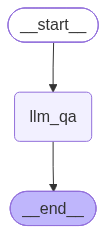

In [7]:
try:
    display(Image(workflow.get_graph().draw_mermaid_png()))
except Exception:
    print("Mermaid renderer unavailable. Displaying ASCII graph:\n")
    print(workflow.get_graph().draw_ascii())